# Example usage of ReactionDiffusion as a library

This refactor was done to enable comfortable use as a library and especially inside a notebook. The entrypoint to create some nice images is the `ExperimentLibrary` that lets you access the already existing experiment presets.

In [1]:
import ReactionDiffusion

library = ReactionDiffusion.ExperimentLibrary()
library.print()

gray_scott_solitons            Stable localised spots that persist and slowly move.
gray_scott_coral               Coral-like branching structures with slow, organic growth.
gray_scott_maze                Dense labyrinthine stripes filling the domain.
gray_scott_waves               Travelling wave fronts that sweep across the domain.
gray_scott_flicker             Unstable spots that appear, flicker, and annihilate.
gray_scott_worms               Worm-like moving filaments with occasional branching.
gierer_meinhardt               Activator-inhibitor system producing spot and stripe Turing patterns.
fitzhugh_nagumo                Excitable medium producing spiral waves. Requires fine timestepping — allow at least 80000 steps for patterns to emerge.


In [2]:
model, grid, renderer = library.fetch('gierer_meinhardt')

Now we can run the model in the notebook. 

(<Figure size 640x480 with 1 Axes>, <Axes: >)

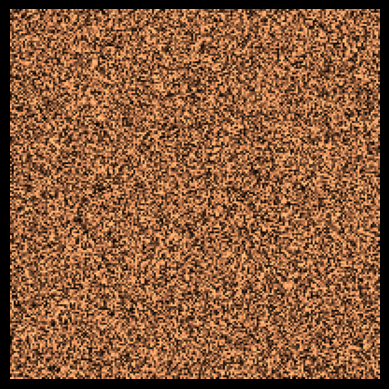

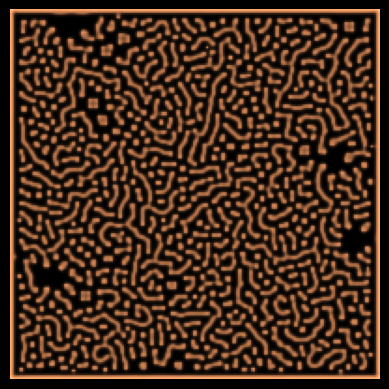

In [3]:
import numpy as np

np.random.seed(187)     # fix the random seed for reproducibility
renderer.to_image(grid) # show state before run
model.run(grid, 1000)   # run 1000 time steps
renderer.to_image(grid) # show state after run

Model settings are easily retrieved and manipulated, nudging the model in a different direction.

In [4]:
model

Gierer–Meinhardt Model:
  diffusion_u         2.0
  diffusion_v         0.1
  reaction_rate       0.5
  saturation_coeff    0.238
  inhibitor_decay     1.0
  activator_decay     0.9
  time_step           0.1

(<Figure size 640x480 with 1 Axes>, <Axes: >)

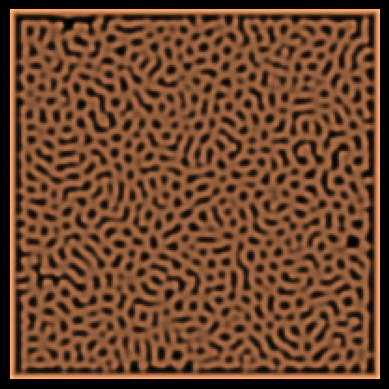

In [5]:
model.inhibitor_decay = 0.7
model.run(grid, 1000)
renderer.to_image(grid)

This refactor also adds `Pillow` based rendering capabilities. The renderer is easily swapped.

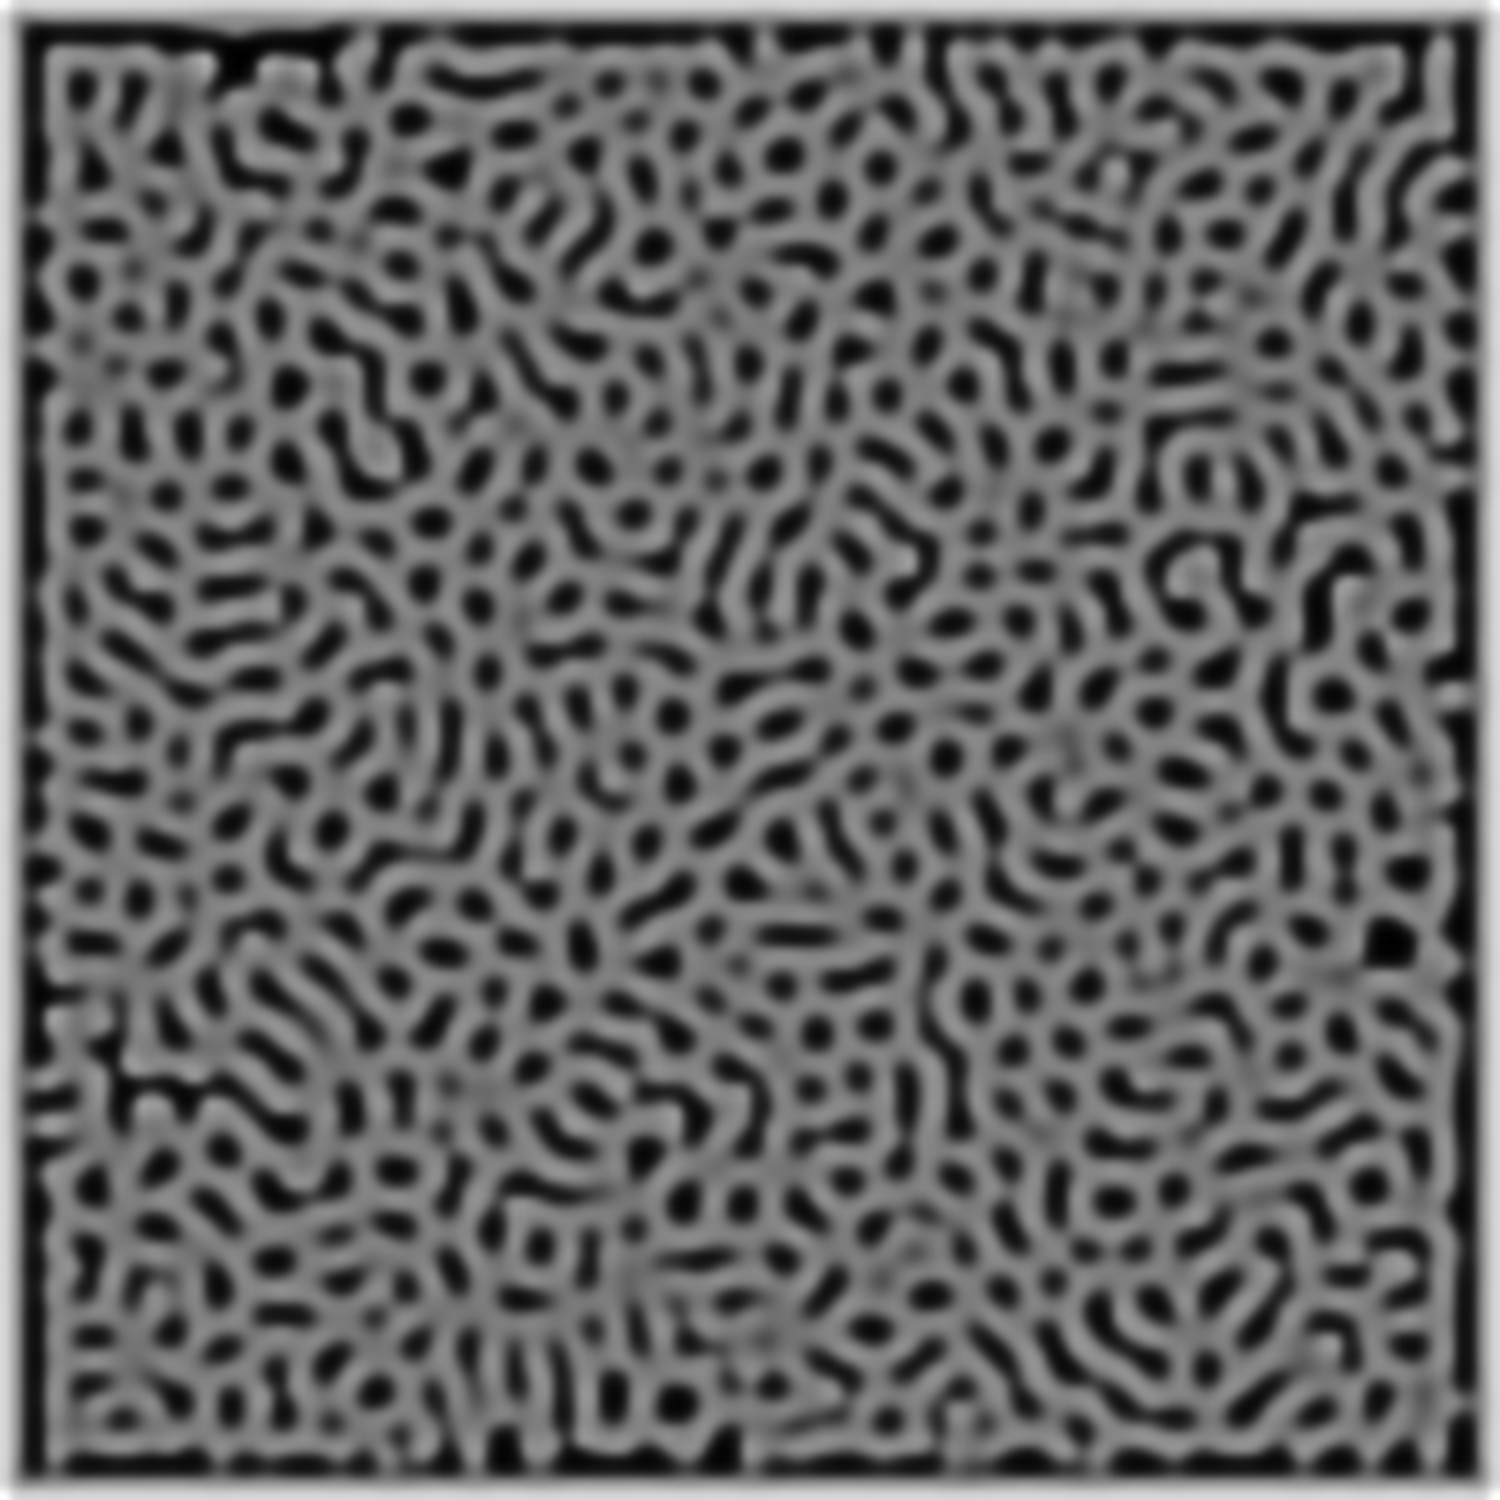

In [7]:
renderer = ReactionDiffusion.PillowRenderer(renderer.params())
renderer.to_image(grid)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

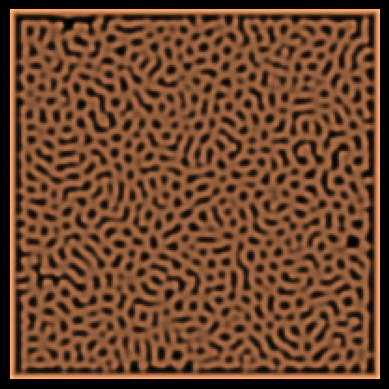

In [8]:
renderer = ReactionDiffusion.MatplotlibRenderer(renderer.params())
renderer.to_image(grid)